In [1]:
library(auk)
library(tidyverse)

library(magrittr)
library(httr)
library(data.table)
library(plotly)
# library(elevatr)
library(readr)
library(raster)

library(sf)
library(terra)
# library(prism)
# library(rnaturalearth)
library(dggridR)
library(lubridate)
library(hms)

library(gridExtra)

select <- dplyr::select
projection <- raster::projection

readRenviron("~/.Renviron")
R.home()

auk 0.9.0 is designed for EBD files downloaded after 2025-10-28. 
No EBD data directory set, see ?auk_set_ebd_path to set EBD_PATH 
eBird taxonomy version:  2025

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘magrittr’


The following object is masked from ‘package:purrr’:

    set_names


The following object is masked from ‘package:tidyr’:

    extract



Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, isoyear, mday, minute, month

[1] "/usr/lib/R"

In [2]:
PROJECT_DIR = getwd()

ebd_dir = file.path(PROJECT_DIR, "source_data", "ebd_relMar-2026")
ebd_filename = "ebd_relMar-2026.txt"

sed_dir = file.path(PROJECT_DIR, "source_data", "ebd_sampling_relMar-2026")
sed_filename = "ebd_sampling_relMar-2026.txt"

auk_version()
# auk_ebd_version(file.path(ebd_dir, ebd_filename))

$auk_version
[1] "auk 0.9.0"

$ebd_version
[1] "2025-10-28"

$taxonomy_version
[1] 2025

<span style="color:deepskyblue">Citation:  
*eBird Basic Dataset. Version: EBD_relMar-2026. Cornell Lab of Ornithology, Ithaca, New York. Mar 2026.*</span>

### Extract with `auk`

####
---

In [ ]:
# print all columns
readLines(file.path(ebd_dir, ebd_filename), n = 1) |> strsplit("\t") |> unlist()

[1] "GLOBAL UNIQUE IDENTIFIER"   "LAST EDITED DATE"          
 [3] "TAXONOMIC ORDER"            "CATEGORY"                  
 [5] "TAXON CONCEPT ID"           "COMMON NAME"               
 [7] "SCIENTIFIC NAME"            "SUBSPECIES COMMON NAME"    
 [9] "SUBSPECIES SCIENTIFIC NAME" "EXOTIC CODE"               
[11] "OBSERVATION COUNT"          "BREEDING CODE"             
[13] "BREEDING CATEGORY"          "BEHAVIOR CODE"             
[15] "AGE/SEX"                    "COUNTRY"                   
[17] "COUNTRY CODE"               "STATE"                     
[19] "STATE CODE"                 "COUNTY"                    
[21] "COUNTY CODE"                "IBA CODE"                  
[23] "BCR CODE"                   "USFWS CODE"                
[25] "ATLAS BLOCK"                "LOCALITY"                  
[27] "LOCALITY ID"                "LOCALITY TYPE"             
[29] "LATITUDE"                   "LONGITUDE"                 
[31] "OBSERVATION DATE"           "TIME OBSERVATIONS STARTED" 
[33] "OBSERVER ID"                "OBSERVER ORCID ID"         
[35] "SAMPLING EVENT IDENTIFIER"  "OBSERVATION TYPE"          
[37] "PROTOCOL NAME"              "PROTOCOL CODE"             
[39] "PROJECT NAMES"              "PROJECT IDENTIFIERS"       
[41] "DURATION MINUTES"           "EFFORT DISTANCE KM"        
[43] "EFFORT AREA HA"             "NUMBER OBSERVERS"          
[45] "ALL SPECIES REPORTED"       "GROUP IDENTIFIER"          
[47] "HAS MEDIA"                  "APPROVED"                  
[49] "REVIEWED"                   "REASON"                    
[51] "CHECKLIST COMMENTS"         "SPECIES COMMENTS"

#### <span style="color: green">Combining all raptors into one pull, larger geo range, 2010-2026 only</span>

In [ ]:
file.desc <- "all_raptors_20260821"
f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, ".txt"))
f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", file.desc, ".txt"))

species_names = c(
    "American Goshawk",
    "American Kestrel",
    "Bald Eagle",
    "Barred Owl",
    "Broad-winged Hawk",
    "Burrowing Owl",
    "Cooper's Hawk",
    "Crested Caracara",
    "Ferruginous Hawk",
    "Flammulated Owl",
    "Golden Eagle",
    "Great Horned Owl",
    "Harris's Hawk",
    "Long-eared Owl",
    "Merlin",
    "Mississippi Kite",
    "Northern Harrier",
    "Osprey",
    "Peregrine Falcon",
    "Red-shouldered Hawk",
    "Red-tailed Hawk",
    "Sharp-shinned Hawk",
    "Short-eared Owl",
    "Swainson's Hawk",
    "Swallow-tailed Kite",
    "White-tailed Kite"
)
# Full dataset filtering
f_in_ebd <- file.path(ebd_dir, ebd_filename)
f_in_sed <- file.path(sed_dir, sed_filename)
ebd_filters <- auk_ebd(f_in_ebd, file_sampling = f_in_sed) %>%
    auk_species(species_names) %>%
    auk_bbox(bbox = c(longitude_min = -140, latitude_min = -30, longitude_max = -40, latitude_max = 65)) %>%
    auk_date(c("*-07-01", "*-12-31")) %>%
    auk_year(2010:2026) %>%
    auk_complete()
# filters: https://cornelllabofornithology.github.io/auk/reference/index.html#section-filter

auk_filter(ebd_filters, file = f_out_ebd_only, file_sampling = f_out_sed_only,
           overwrite = TRUE)

Warning message in auk_species.auk_ebd(., species_names):
“Based on the EBD filename, it appears you should use taxonomy_version = 2025”


Input 
  EBD: /media/user797/exHDD-02/ebd_relMar-2026/ebd_relMar-2026.txt 
  Sampling events: /media/user797/exHDD-02/ebd_sampling_relMar-2026/ebd_sampling_relMar-2026.txt 

Output 
  EBD: /home/user797/Storage_Root/Tech/Projects/CS_416_Final_Project/output/auk/ebd_all_raptors_20260818.txt 
  Sampling events: /home/user797/Storage_Root/Tech/Projects/CS_416_Final_Project/output/auk/sed_all_raptors_20260818.txt 

Filters 
  Species: 26 species
  Countries: all
  States: all
  Counties: all
  BCRs: all
  Bounding box: Lon -140 - -40; Lat -30 - 65
  Years: 17 years
  Date: *-07-01 - *-12-31
  Start time: all
  Last edited date: all
  Protocol: all
  Project code: all
  Duration: all
  Distance travelled: all
  Records with breeding codes only: no
  Exotic Codes: all
  Complete checklists only: yes

In [ ]:
species_names = c(
    "American Goshawk",
    "American Kestrel",
    "Bald Eagle",
    "Barred Owl",
    "Broad-winged Hawk",
    "Burrowing Owl",
    "Cooper's Hawk",
    "Crested Caracara",
    "Ferruginous Hawk",
    "Flammulated Owl",
    "Golden Eagle",
    "Great Horned Owl",
    "Harris's Hawk",
    "Long-eared Owl",
    "Merlin",
    "Mississippi Kite",
    "Northern Harrier",
    "Osprey",
    "Peregrine Falcon",
    "Red-shouldered Hawk",
    "Red-tailed Hawk",
    "Sharp-shinned Hawk",
    "Short-eared Owl",
    "Swainson's Hawk",
    "Swallow-tailed Kite",
    "White-tailed Kite"
)
file.desc <- "all_raptors_20260821"
f_full_ebd <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, ".txt"))

prefix <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, "_"))
species_files <- auk_split(f_full_ebd, species = species_names, prefix = prefix, overwrite = TRUE)

####
<span style="color: green">

---

</span>

#### Split each file into two parts to avoid memory issues with the zero-filling or whatever was having an issue below when input-file size was too large.

In [ ]:
# Run "loop" once w/ sampling data included so it gets split, but redundant to keep it included for every species.
# Will write out the same two split SED files every time (and they're the slowest part)

prefix <- "all_raptors_20260821"
species.names <- c(
 "Accipiter_striatus"
)

for (species.name in species.names) {
    file.desc <- paste0(prefix, "_", species.name)
    f_in_ebd <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, ".txt"))
    f_in_sed <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", prefix, ".txt"))

    # 1   #######################
    f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, "_1.txt"))
    f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", prefix, "_1.txt"))
    auk_ebd(f_in_ebd
          , file_sampling = f_in_sed     # Have to split SED once for all species, so only include it in first-species run
            ) %>%
        auk_date(c("*-07-01", "*-09-30")) %>%
        auk_filter(file = f_out_ebd_only,
                   file_sampling = f_out_sed_only,      # Have to split SED once for all species, so only include it in first-species run
                   keep = c("SCIENTIFIC NAME", "OBSERVATION COUNT",
                           "LATITUDE", "LONGITUDE", "COUNTRY", "COUNTRY CODE", "STATE", "STATE CODE",
                           "OBSERVATION DATE", "TIME OBSERVATIONS STARTED", "DURATION MINUTES",
                           "EFFORT DISTANCE KM", "NUMBER OBSERVERS", "PROTOCOL NAME", "ALL SPECIES REPORTED",
                           "SAMPLING EVENT IDENTIFIER", "OBSERVER ID", "GROUP IDENTIFIER"),
                  #  overwrite = TRUE
                   )

    # 2   #######################
    f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, "_2.txt"))
    f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", prefix, "_2.txt"))
    auk_ebd(f_in_ebd
          , file_sampling = f_in_sed     # Have to split SED once for all species, so only include it in first-species run
            ) %>%
        auk_date(c("*-10-01", "*-12-31")) %>%
        auk_filter(file = f_out_ebd_only,
                   file_sampling = f_out_sed_only,      # Have to split SED once for all species, so only include it in first-species run
                   keep = c("SCIENTIFIC NAME", "OBSERVATION COUNT",
                            "LATITUDE", "LONGITUDE", "COUNTRY", "COUNTRY CODE", "STATE", "STATE CODE",
                            "OBSERVATION DATE", "TIME OBSERVATIONS STARTED", "DURATION MINUTES",
                            "EFFORT DISTANCE KM", "NUMBER OBSERVERS", "PROTOCOL NAME", "ALL SPECIES REPORTED",
                            "SAMPLING EVENT IDENTIFIER", "OBSERVER ID", "GROUP IDENTIFIER"),
                  #  overwrite = TRUE
                   )
}

Warning message in auk_filter.auk_ebd(., file = f_out_ebd_only, file_sampling = f_out_sed_only, :
“Sampling event data file provided, but filters have not been  set to only return complete checklists. Complete checklists  are required for zero-filling. You may want to use  auk_complete(), or manually filter out incomplete checklists.”
Warning message in auk_filter.auk_ebd(., file = f_out_ebd_only, file_sampling = f_out_sed_only, :
“Sampling event data file provided, but filters have not been  set to only return complete checklists. Complete checklists  are required for zero-filling. You may want to use  auk_complete(), or manually filter out incomplete checklists.”


In [ ]:
prefix <- "all_raptors_20260821"

species.names <- c(
#  "Accipiter_striatus",   # run separately above w/ SED included
 "Aquila_chrysaetos",
 "Asio_flammeus",
 "Asio_otus",
 "Astur_atricapillus",
 "Astur_cooperii",
 "Athene_cunicularia",
 "Bubo_virginianus",
 "Buteo_jamaicensis",
 "Buteo_lineatus",
 "Buteo_platypterus",
 "Buteo_regalis",
 "Buteo_swainsoni",
 "Caracara_plancus",
 "Circus_hudsonius",
 "Elanoides_forficatus",
 "Elanus_leucurus",
 "Falco_columbarius",
 "Falco_peregrinus",
 "Falco_sparverius",
 "Haliaeetus_leucocephalus",
 "Ictinia_mississippiensis",
 "Pandion_haliaetus",
 "Parabuteo_unicinctus",
 "Psiloscops_flammeolus", 
 "Strix_varia"
 )

for (species.name in species.names) {
    file.desc <- paste0(prefix, "_", species.name)
    f_in_ebd <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, ".txt"))
    f_in_sed <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", prefix, ".txt"))

    # 1   #######################
    f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, "_1.txt"))
    f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", prefix, "_1.txt"))
    auk_ebd(f_in_ebd
          # , file_sampling = f_in_sed     # Have to split SED once for all species, so only included this in first-species run
            ) %>%
        auk_date(c("*-07-01", "*-09-30")) %>%
        auk_filter(file = f_out_ebd_only,
                  #  file_sampling = f_out_sed_only,      # Have to split SED once for all species, so only included this in first-species run
                   keep = c("SCIENTIFIC NAME", "OBSERVATION COUNT",
                           "LATITUDE", "LONGITUDE", "COUNTRY", "COUNTRY CODE", "STATE", "STATE CODE",
                           "OBSERVATION DATE", "TIME OBSERVATIONS STARTED", "DURATION MINUTES",
                           "EFFORT DISTANCE KM", "NUMBER OBSERVERS", "PROTOCOL NAME", "ALL SPECIES REPORTED",
                           "SAMPLING EVENT IDENTIFIER", "OBSERVER ID", "GROUP IDENTIFIER"),
                  #  overwrite = TRUE
                   )

    # 2   #######################
    f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, "_2.txt"))
    f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", prefix, "_2.txt"))
    auk_ebd(f_in_ebd
          # , file_sampling = f_in_sed     # Have to split SED once for all species, so only included this in first-species run
            ) %>%
        auk_date(c("*-10-01", "*-12-31")) %>%
        auk_filter(file = f_out_ebd_only,
                  #  file_sampling = f_out_sed_only,      # Have to split SED once for all species, so only included this in first-species run
                   keep = c("SCIENTIFIC NAME", "OBSERVATION COUNT",
                            "LATITUDE", "LONGITUDE", "COUNTRY", "COUNTRY CODE", "STATE", "STATE CODE",
                            "OBSERVATION DATE", "TIME OBSERVATIONS STARTED", "DURATION MINUTES",
                            "EFFORT DISTANCE KM", "NUMBER OBSERVERS", "PROTOCOL NAME", "ALL SPECIES REPORTED",
                            "SAMPLING EVENT IDENTIFIER", "OBSERVER ID", "GROUP IDENTIFIER"),
                  #  overwrite = TRUE
                   )
}

#### <span style="color: springgreen">Read extracted data in</span>

In [3]:
# file.desc <- "swallow_tailed_kite_compl_exp_range_20260729"
# file.desc <- "broad_winged_hawk_compl_exp_range_20260729"
# file.desc <- "mississippi_kite_compl_20260726"
# file.desc <- "peregrine_falcon_compl_20260727"
# file.desc <- "swainsons_hawk_compl_20260727"
# file.desc <- "ss_hawk_compl_20260801"
# file.desc <- "merlin_compl_20260801"
# file.desc <- "n_harrier_compl_20260801"
# file.desc <- "osprey_compl_20260801"

# file.desc <- "mississippi_kite_compl_exp1_20260803"
# file.desc <- "mississippi_kite_compl_exp2_20260803"
# file.desc <- "osprey_compl_exp1_20260803"
file.desc <- "osprey_compl_exp2_20260803"

f_out_ebd_only <- file.path(PROJECT_DIR, "output", "auk", paste0("ebd_", file.desc, ".txt"))
f_out_sed_only <- file.path(PROJECT_DIR, "output", "auk", paste0("sed_", file.desc, ".txt"))

ebd_only_df = read_ebd(f_out_ebd_only, unique=TRUE, rollup=TRUE) # do not need to use auk_unique() when unique=TRUE passed here. Same for auk_rollup()
sed_only_df = read_sampling(f_out_sed_only, unique=TRUE)

In [13]:
str(ebd_only_df)

tibble [57,993 × 21] (S3: tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:57993] "G10000252" "G10000296" "G1000625" "G1001498" ...
 $ scientific_name          : chr [1:57993] "Elanoides forficatus" "Elanoides forficatus" "Elanoides forficatus" "Elanoides forficatus" ...
 $ observation_count        : chr [1:57993] "2" "1" "2" "1" ...
 $ country                  : chr [1:57993] "United States" "United States" "United States" "Ecuador" ...
 $ country_code             : chr [1:57993] "US" "US" "US" "EC" ...
 $ state                    : chr [1:57993] "Florida" "Florida" "Florida" "Orellana" ...
 $ state_code               : chr [1:57993] "US-FL" "US-FL" "US-FL" "EC-D" ...
 $ latitude                 : num [1:57993] 28.663 27.931 24.742 -0.444 9.231 ...
 $ longitude                : num [1:57993] -80.7 -81.2 -81 -76.7 -83.4 ...
 $ observation_date         : Date[1:57993], format: "2010-07-15" "2010-07-18" ...
 $ time_observations_started: chr [1:57993] NA NA "09:00:00" "12:00:00

In [32]:
str(sed_only_df)

tibble [9,574,077 × 17] (S3: tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:9574077] "S34352907" "S7223310" "S60476468" "S60413427" ...
 $ country                  : chr [1:9574077] "United States" "United States" "United States" "United States" ...
 $ country_code             : chr [1:9574077] "US" "US" "US" "US" ...
 $ state                    : chr [1:9574077] "Louisiana" "Texas" "Indiana" "Louisiana" ...
 $ state_code               : chr [1:9574077] "US-LA" "US-TX" "US-IN" "US-LA" ...
 $ latitude                 : num [1:9574077] 29.8 26.3 38.9 29.8 35.6 ...
 $ longitude                : num [1:9574077] -93.7 -97.4 -86.4 -93.5 -105.9 ...
 $ observation_date         : Date[1:9574077], format: "1987-11-14" "1992-08-04" ...
 $ time_observations_started: chr [1:9574077] "15:00:00" "07:00:00" NA "08:00:00" ...
 $ observer_id              : chr [1:9574077] "obsr116124" "obsr229232" "obsr614875" "obsr128996" ...
 $ sampling_event_identifier: chr [1:9574077] "S34352907" "S7223

### Clean and Filter

#### Zero-fill

In [4]:
ebd_zf_df <- auk_zerofill(ebd_only_df, sampling_events = sed_only_df,
                          collapse = TRUE)

#### Clean

In [ ]:
str(ebd_zf_df)

In [5]:
# function to convert time observation to hours since midnight
time_to_decimal <- function(x) {
  x <- as_hms(x)
  hour(x) + minute(x) / 60 + second(x) / 3600
}

ebd_df <- ebd_zf_df |> 
  mutate(
    # convert count to integer and X to NA
    observation_count = if_else(observation_count == "X", 
                                NA_character_, observation_count),
    observation_count = as.integer(observation_count),
    # ignore the warning "NAs introduced by coercion"
    effort_distance_km = if_else(protocol_name == "Stationary", 
                                  0, effort_distance_km),
    # convert time to decimal hours since midnight
    hours_of_day = time_to_decimal(time_observations_started),
    # split date into year and day of year
    year = year(observation_date),
    day_of_year = yday(observation_date)
  )

table(ebd_zf_df$species_observed)
# Removed effort-variability filter. Want to see all observations.
# https://strimas.com/ebp-workshop/presabs.html


   FALSE     TRUE 
15822721   695563 

In [ ]:
str(ebd_df)

# A tibble: 1 × 8
        n min_year   p05    q1 median_year    q3   p95 max_year
    <int>    <dbl> <dbl> <dbl>       <dbl> <dbl> <dbl>    <dbl>
1 5833289     1838  2010  2018        2021  2023  2025     2025


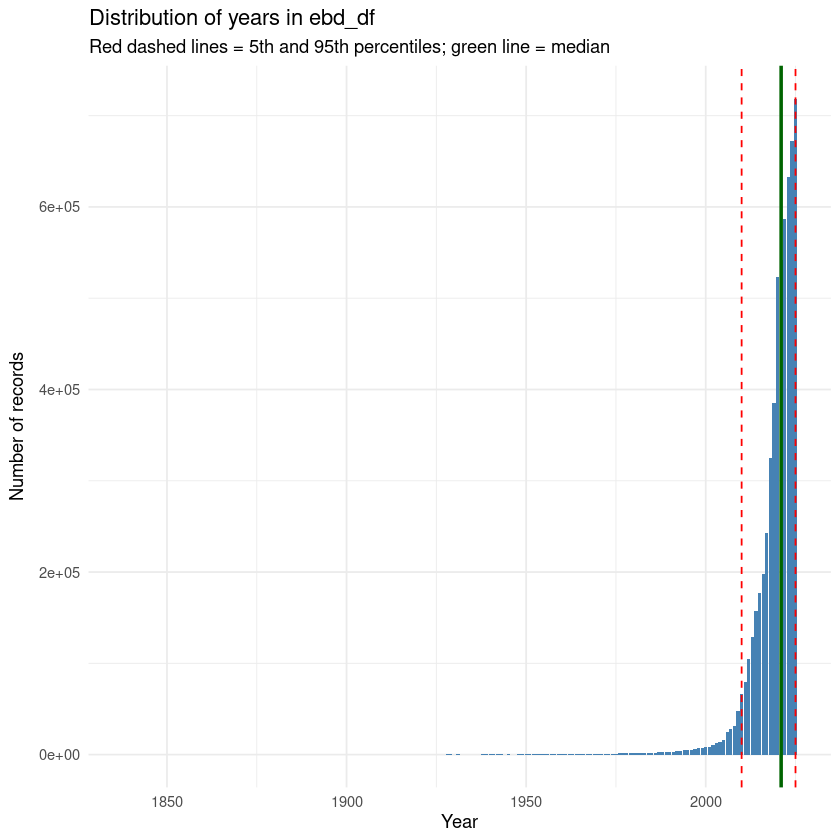

In [8]:
year_stats <- ebd_df %>%
    filter(!is.na(year)) %>%
    summarize(
        n = n(),
        min_year = min(year),
        p05 = quantile(year, 0.05),
        q1 = quantile(year, 0.25),
        median_year = median(year),
        q3 = quantile(year, 0.75),
        p95 = quantile(year, 0.95),
        max_year = max(year)
    )

print(year_stats)

year_counts <- ebd_df %>%
    filter(!is.na(year)) %>%
    count(year)

ggplot(year_counts, aes(x = year, y = n)) +
    geom_col(fill = "steelblue") +
    geom_vline(xintercept = c(year_stats$p05, year_stats$p95),
                         linetype = "dashed", color = "red") +
    geom_vline(xintercept = year_stats$median_year,
                         color = "darkgreen", linewidth = 1) +
    labs(
        title = "Distribution of years in ebd_df",
        subtitle = "Red dashed lines = 5th and 95th percentiles; green line = median",
        x = "Year",
        y = "Number of records"
    ) +
    theme_minimal()

#### <span style="color: violet">Write out</span>

In [6]:
# file.desc <- "swallow_tailed_kite_compl_exp_range_20260729"
# file.desc <- "broad_winged_hawk_compl_exp_range_20260729"
# file.desc <- "mississippi_kite_compl_20260726"
# file.desc <- "peregrine_falcon_compl_20260727"
# file.desc <- "swainsons_hawk_compl_20260727"
# file.desc <- "ss_hawk_compl_20260801"
# file.desc <- "merlin_compl_20260801"
# file.desc <- "n_harrier_compl_20260801"
# file.desc <- "osprey_compl_20260801"

# file.desc <- "mississippi_kite_compl_exp1_20260803"
# file.desc <- "mississippi_kite_compl_exp2_20260803"
# file.desc <- "osprey_compl_exp1_20260803"
file.desc <- "osprey_compl_exp2_20260803"

In [7]:
write_csv(ebd_df, file.path(PROJECT_DIR, "output", paste0(file.desc, "_zf_clean.csv")))
# library(arrow)
# write_parquet(ebd_df, file.path(PROJECT_DIR, "output", paste0(file.desc, "_zf_clean.parquet")))

In [ ]:
head(ebd_df)

#### <span style="color: springgreen">Read (zf+clean) data back in</span>

In [7]:
# file.desc <- "swallow_tailed_kite_compl_exp_range_20260729"
# file.desc <- "broad_winged_hawk_compl_exp_range_20260729"
# file.desc <- "mississippi_kite_compl_20260726"
# file.desc <- "peregrine_falcon_compl_20260727"
# file.desc <- "swainsons_hawk_compl_20260727"
# file.desc <- "ss_hawk_compl_20260801"
# file.desc <- "merlin_compl_20260801"
# file.desc <- "n_harrier_compl_20260801"
# file.desc <- "osprey_compl_20260801"

file.desc <- "mississippi_kite_compl_exp1_20260803"
# file.desc <- "mississippi_kite_compl_exp2_20260803"
# file.desc <- "osprey_compl_exp1_20260803"
# file.desc <- "osprey_compl_exp2_20260803"

In [8]:
ebd_df = read_csv(file.path(PROJECT_DIR, "output", paste0(file.desc, "_zf_clean.csv")))
head(ebd_df)
# re-back-in data giving another type of data structure for some reason

Rows: 15902424 Columns: 23
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (10): checklist_id, country, country_code, state, state_code, observer_...
dbl   (9): latitude, longitude, duration_minutes, effort_distance_km, number...
lgl   (2): all_species_reported, species_observed
date  (1): observation_date
time  (1): time_observations_started

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


checklist_id,country,country_code,state,state_code,latitude,longitude,observation_date,time_observations_started,observer_id,⋯,effort_distance_km,number_observers,all_species_reported,group_identifier,scientific_name,observation_count,species_observed,hours_of_day,year,day_of_year
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<date>,<time>,<chr>,⋯,<dbl>,<dbl>,<lgl>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
S80339480,Canada,CA,Alberta,CA-AB,50.65949,-114.57316,1983-07-24,09:00:00,obsr382575,⋯,3,3,TRUE,NA,Ictinia mississippiensis,0,FALSE,9.000000,1983,205
S68576532,Canada,CA,Ontario,CA-ON,43.84295,-78.96434,1980-08-17,08:00:00,obsr419506,⋯,3,1,TRUE,NA,Ictinia mississippiensis,0,FALSE,8.000000,1980,230
S59877712,Canada,CA,Ontario,CA-ON,43.84295,-78.96434,1996-09-01,NA,obsr804968,⋯,NA,1,TRUE,NA,Ictinia mississippiensis,0,FALSE,NA,1996,245
S112142291,Canada,CA,Ontario,CA-ON,43.84295,-78.96434,1974-09-12,09:35:00,obsr817532,⋯,0,1,TRUE,NA,Ictinia mississippiensis,0,FALSE,9.583333,1974,255
S60414543,United States,US,Washington,US-WA,46.03938,-118.93880,1995-09-13,NA,obsr201374,⋯,NA,2,TRUE,NA,Ictinia mississippiensis,0,FALSE,NA,1995,256
S60414576,United States,US,Washington,US-WA,46.05602,-118.90220,1996-07-10,NA,obsr201374,⋯,NA,2,TRUE,NA,Ictinia mississippiensis,0,FALSE,NA,1996,192


#### <span style="color:grey">Not filtering for effort</span>

### Aggregate: bin checklist locations into hex grid and bin dates into weeks

In [8]:
# construct grid
grid_res_km <- 50
dggs <- dgconstruct(spacing = grid_res_km, topology = "HEXAGON")

# get hexagonal cell id and week number for each checklist
ebd_with_cells <- ebd_df |>
  mutate(cell = dgGEO_to_SEQNUM(dggs, longitude, latitude)$seqnum,
         week = isoweek(observation_date))
# https://strimas.com/ebp-workshop/subsampling.html
str(ebd_with_cells)

# generate polygons for the grid cells
# hexagons <- dgcellstogrid(dggs, unique(pts$cell), frame = FALSE) %>% 
hexagons <- dgcellstogrid(dggs, unique(ebd_with_cells$cell)) %>% 
  st_as_sf()

hexagons$cell <- as.integer(hexagons$seqnum)
# convert to terra SpatVector
hexagons <- hexagons %>% select(cell, geometry)
hex_spatvector <- terra::vect(hexagons)

Resolution: 9, Area (km^2): 2591.40182758771, Spacing (km): 50.276890494384, CLS (km): 57.4411078487275
tibble [16,518,284 × 25] (S3: tbl_df/tbl/data.frame)
 $ checklist_id             : chr [1:16518284] "S68913224" "S114884742" "S20606944" "S60410967" ...
 $ country                  : chr [1:16518284] "Canada" "Canada" "Canada" "United States" ...
 $ country_code             : chr [1:16518284] "CA" "CA" "CA" "US" ...
 $ state                    : chr [1:16518284] "Ontario" "Ontario" "Ontario" "Arkansas" ...
 $ state_code               : chr [1:16518284] "CA-ON" "CA-ON" "CA-ON" "US-AR" ...
 $ latitude                 : num [1:16518284] 43.8 43.8 43.8 34.8 34.8 ...
 $ longitude                : num [1:16518284] -79 -79 -79 -91.8 -91.8 ...
 $ observation_date         : Date[1:16518284], format: "1980-10-04" "1980-10-10" ...
 $ time_observations_started: chr [1:16518284] "09:30:00" "10:00:00" "09:30:00" "07:00:00" ...
 $ observer_id              : chr [1:16518284] "obsr419506" "obsr817532

In [11]:
hex_spatvector

 class       : SpatVector 
 geometry    : polygons 
 dimensions  : 9628, 1  (geometries, attributes)
 extent      : -125.8585, -49.26501, -15.47016, 65.39177  (xmin, xmax, ymin, ymax)
 coord. ref. : lon/lat WGS 84 (EPSG:4326) 
 names       :  cell
 type        : <int>
 values      :  5540
                5622
                5865

In [9]:
ebd_agg <- ebd_with_cells %>% 
  group_by(cell) %>% 
  summarize(n_checklists = n(),
            n_detected = sum(species_observed),
            det_freq = mean(species_observed),
            tot_observed = sum(observation_count),
            first_date = min(observation_date),
            last_date = max(observation_date),
            country_code = names(sort(table(country_code), decreasing = TRUE))[1]) %>% 
  ungroup() %>%
  mutate(cell_ctr_lat = dgSEQNUM_to_GEO(dggs, cell)$lat_deg,
         cell_ctr_lon = dgSEQNUM_to_GEO(dggs, cell)$lon_deg)
# https://www.rdocumentation.org/packages/dggridR/versions/3.1.0/topics/dgSEQNUM_to_GEO

ebd_agg_weekly <- ebd_with_cells %>% 
  group_by(cell, week) %>% 
  summarize(n_checklists = n(),
            n_detected = sum(species_observed),
            det_freq = mean(species_observed),
            tot_observed = sum(observation_count),
            country_code = names(sort(table(country_code), decreasing = TRUE))[1]) %>% 
  ungroup() %>%
  mutate(cell_ctr_lat = dgSEQNUM_to_GEO(dggs, cell)$lat_deg,
         cell_ctr_lon = dgSEQNUM_to_GEO(dggs, cell)$lon_deg)
# https://www.rdocumentation.org/packages/dggridR/versions/3.1.0/topics/dgSEQNUM_to_GEO

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by cell and week.
ℹ Output is grouped by cell.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(cell, week))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


In [ ]:
str(ebd_agg)
str(ebd_agg_weekly)

### <span style="color: violet">Write out</span>

In [10]:
# file.desc <- "swallow_tailed_kite_compl_exp_range_20260729"
# file.desc <- "broad_winged_hawk_compl_exp_range_20260729"
# file.desc <- "mississippi_kite_compl_20260726"
# file.desc <- "peregrine_falcon_compl_20260727"
# file.desc <- "swainsons_hawk_compl_20260727"
# file.desc <- "ss_hawk_compl_20260801"
# file.desc <- "merlin_compl_20260801"
# file.desc <- "n_harrier_compl_20260801"
# file.desc <- "osprey_compl_20260801"

# file.desc <- "mississippi_kite_compl_exp1_20260803"
# file.desc <- "mississippi_kite_compl_exp2_20260803"
# file.desc <- "osprey_compl_exp1_20260803"
file.desc <- "osprey_compl_exp2_20260803"

write_csv(ebd_agg_weekly, file.path(PROJECT_DIR, "output", paste0(file.desc, "_zf_clean_agg_weekly.csv")))

In [57]:
dim(ebd_agg)

[1] 5833    9

In [58]:
head(ebd_agg)

cell,n_checklists,n_detected,det_freq,tot_observed,first_date,last_date,cell_ctr_lat,cell_ctr_lon
<dbl>,<int>,<int>,<dbl>,<dbl>,<date>,<date>,<dbl>,<dbl>
14221,12,0,0,0,2004-07-08,2025-08-13,40.08216,-108.0307
14303,398,0,0,0,1968-09-14,2025-09-19,40.06873,-107.4245
14384,2061,0,0,0,1984-08-10,2025-11-30,39.62537,-107.8115
14385,217,0,0,0,1980-08-04,2025-11-12,40.05224,-106.8187
14464,412,0,0,0,1965-07-01,2025-10-15,39.17990,-108.1964
14465,4510,0,0,0,1966-07-11,2025-11-29,39.61076,-107.2108


In [51]:
dim(ebd_agg_weekly)

[1] 74479     8

In [54]:
head(ebd_agg_weekly)

cell,week,n_checklists,n_detected,det_freq,tot_observed,cell_ctr_lat,cell_ctr_lon
<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
14221,26,1,0,0,0,40.08216,-108.0307
14221,27,1,0,0,0,40.08216,-108.0307
14221,28,2,0,0,0,40.08216,-108.0307
14221,29,1,0,0,0,40.08216,-108.0307
14221,30,1,0,0,0,40.08216,-108.0307
14221,31,2,0,0,0,40.08216,-108.0307


In [ ]:
min(ebd_agg_weekly$week)
max(ebd_agg_weekly$week)

[1] 26

[1] 49

### <span style="color: skyblue">Combine agg data from separate extractions after clean/zf/agg</span>

In [18]:
require(dplyr)
require(readr)
require(purrr)

combine_chunk_aggs <- function(files) {
  bind_rows(map(files, read_csv, show_col_types = FALSE)) %>%
    group_by(cell, week) %>%
    summarise(
      n_checklists = sum(n_checklists, na.rm = TRUE),
      n_detected   = sum(n_detected, na.rm = TRUE),
      tot_observed = sum(tot_observed, na.rm = TRUE),
      cell_ctr_lat = first(na.omit(cell_ctr_lat)),
      cell_ctr_lon = first(na.omit(cell_ctr_lon)),
      country_code = names(sort(table(country_code), decreasing = TRUE))[1],
      .groups = "drop"
    ) %>%
    mutate(
      det_freq = if_else(n_checklists > 0, n_detected / n_checklists, NA_real_)
    )
}

file.descs = c("mississippi_kite_compl_exp1_20260803", "mississippi_kite_compl_exp2_20260803")
# file.descs = c("osprey_compl_exp1_20260803", "osprey_compl_exp2_20260803")

ebd_agg_weekly_comb = combine_chunk_aggs(file.path(PROJECT_DIR, "output", paste0(file.descs, "_zf_clean_agg_weekly.csv")))

In [20]:
head(ebd_agg_weekly_comb)

cell,week,n_checklists,n_detected,tot_observed,cell_ctr_lat,cell_ctr_lon,country_code,det_freq
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
5540,31,2,0,0,64.41843,-125.2839,CA,0
5622,30,1,0,0,64.52753,-124.2267,CA,0
5622,39,1,0,0,64.52753,-124.2267,CA,0
5622,42,1,0,0,64.52753,-124.2267,CA,0
5865,39,1,0,0,63.63552,-123.9812,CA,0
6027,34,1,0,0,63.24120,-123.3523,CA,0


### <span style="color: violet">Write out (combined)</span>

In [21]:
file.desc <- "mississippi_kite_compl_exp1-2comb_20260803"
# file.desc <- "osprey_compl_exp1-2comb_20260803"

write_csv(ebd_agg_weekly_comb, file.path(PROJECT_DIR, "output", paste0(file.desc, "_zf_clean_agg_weekly.csv")))

### <span style="color: springgreen">Read (agg) data back in</span>

In [5]:
# file.desc <- "swallow_tailed_kite_compl_exp_range_20260729"
# file.desc <- "broad_winged_hawk_compl_exp_range_20260729"
# file.desc <- "peregrine_falcon_compl_20260727"
# file.desc <- "swainsons_hawk_compl_20260727"
# file.desc <- "ss_hawk_compl_20260801"
# file.desc <- "merlin_compl_20260801"
# file.desc <- "n_harrier_compl_20260801"
# file.desc <- "mississippi_kite_compl_20260726"
# file.desc <- "osprey_compl_20260801"

# file.desc <- "mississippi_kite_compl_exp1-2comb_20260803"
file.desc <- "osprey_compl_exp1-2comb_20260803"

In [ ]:
ebd_agg_weekly = read_csv(file.path(PROJECT_DIR, "output", paste0(file.desc, "_zf_clean_agg_weekly.csv")))
head(ebd_agg_weekly)

Rows: 173987 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): country_code
dbl (8): cell, week, n_checklists, n_detected, tot_observed, cell_ctr_lat, c...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


cell,week,n_checklists,n_detected,tot_observed,cell_ctr_lat,cell_ctr_lon,country_code,det_freq
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
5540,31,2,0,0,64.41843,-125.2839,CA,0
5622,30,1,0,0,64.52753,-124.2267,CA,0
5622,39,1,0,0,64.52753,-124.2267,CA,0
5622,42,1,0,0,64.52753,-124.2267,CA,0
5865,39,1,0,0,63.63552,-123.9812,CA,0
6027,34,1,0,0,63.24120,-123.3523,CA,0


In [ ]:
ebd_agg_weekly[""].hist()

### Plot

In [38]:
# Reset plotting defaults in case the 1x2 layout cell was run earlier
if (exists("old_par")) {
    par(old_par)
} else {
    par(mfrow = c(1, 1), mar = c(5.1, 4.1, 4.1, 2.1))
}

# Remove custom Jupyter plot size overrides
options(repr.plot.width = NULL, repr.plot.height = NULL)

In [ ]:
plot(hex_spatvector)
# all checklists in bbox

In [ ]:
# Join aggregated data with hexagon spatial vector
hex_with_data <- hexagons %>%
    left_join(ebd_agg, by = "cell") %>%
    mutate(has_observation = (n_detected > 0))

# Convert to terra SpatVector
hex_spatvector_colored <- terra::vect(hex_with_data)

# =======================
hex_with_data_weekly <- hexagons %>%
    left_join(ebd_agg_weekly, by = "cell") %>%
    mutate(has_observation = (n_detected > 0)) %>%
    group_by(cell) %>%
    mutate(cell_has_observation = any(n_detected > 0, na.rm = TRUE)) %>%
    ungroup()

hex_spatvector_colored_weekly <- terra::vect(hex_with_data_weekly)

In [182]:
head(as_tibble(hex_with_data), 10)

cell,n_checklists,n_detected,det_freq,cell_ctr_lat,cell_ctr_lon,geometry,has_observation
<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<POLYGON [°]>,<lgl>
14221,7,0,0,40.08216,-108.0307,POLYGON ((-108.3599 39.9375...,FALSE
14303,216,0,0,40.06873,-107.4245,POLYGON ((-107.7552 39.9257...,FALSE
14384,1196,0,0,39.62537,-107.8115,POLYGON ((-108.1397 39.4811...,FALSE
14385,114,0,0,40.05224,-106.8187,POLYGON ((-107.151 39.91094...,FALSE
14464,202,0,0,39.17990,-108.1964,POLYGON ((-108.5224 39.0343...,FALSE
14465,2608,0,0,39.61076,-107.2108,POLYGON ((-107.5406 39.4681...,FALSE
14466,499,0,0,40.03270,-106.2133,POLYGON ((-106.5471 39.8930...,FALSE
14546,688,0,0,39.16716,-107.6007,POLYGON ((-107.9283 39.0231...,FALSE
14547,3593,0,0,39.59316,-106.6104,POLYGON ((-106.9418 39.4521...,FALSE


In [183]:
head(as_tibble(hex_with_data_weekly), 10)

cell,week,n_checklists,n_detected,det_freq,cell_ctr_lat,cell_ctr_lon,geometry,has_observation,cell_has_observation
<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<POLYGON [°]>,<lgl>,<lgl>
14221,30,1,0,0,40.08216,-108.0307,POLYGON ((-108.3599 39.9375...,FALSE,FALSE
14221,31,2,0,0,40.08216,-108.0307,POLYGON ((-108.3599 39.9375...,FALSE,FALSE
14221,32,1,0,0,40.08216,-108.0307,POLYGON ((-108.3599 39.9375...,FALSE,FALSE
14221,33,2,0,0,40.08216,-108.0307,POLYGON ((-108.3599 39.9375...,FALSE,FALSE
14221,35,1,0,0,40.08216,-108.0307,POLYGON ((-108.3599 39.9375...,FALSE,FALSE
14303,31,10,0,0,40.06873,-107.4245,POLYGON ((-107.7552 39.9257...,FALSE,FALSE
14303,32,16,0,0,40.06873,-107.4245,POLYGON ((-107.7552 39.9257...,FALSE,FALSE
14303,33,46,0,0,40.06873,-107.4245,POLYGON ((-107.7552 39.9257...,FALSE,FALSE
14303,34,5,0,0,40.06873,-107.4245,POLYGON ((-107.7552 39.9257...,FALSE,FALSE


In [203]:
min(hex_spatvector_colored_weekly$week)
max(hex_spatvector_colored_weekly$week)

[1] 30

[1] 44

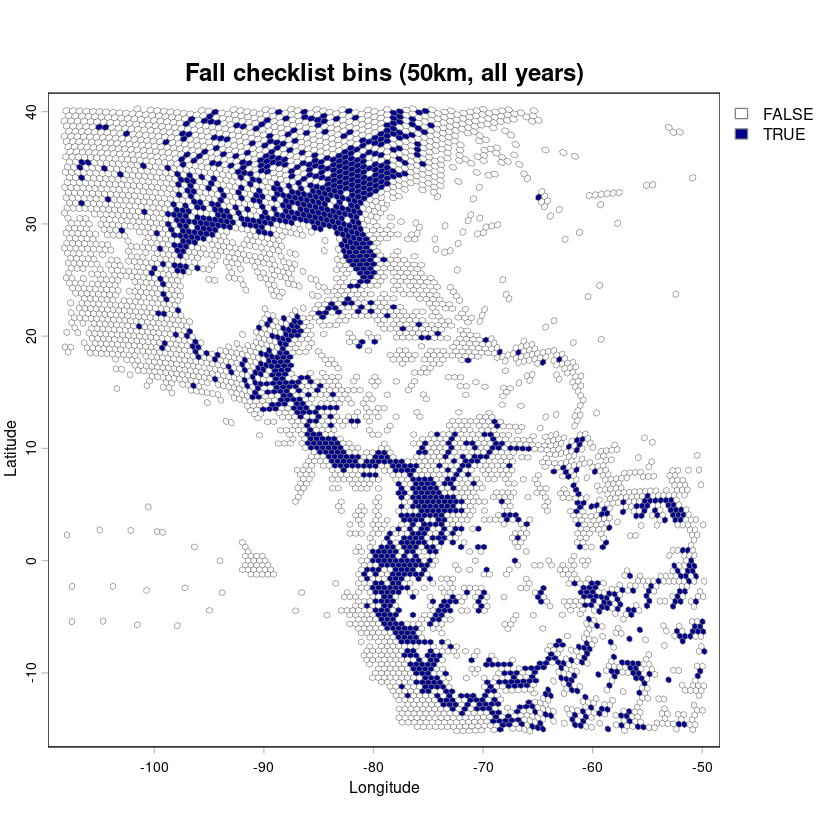

In [184]:
plot(
    hex_spatvector_colored, "has_observation",
    col = c("white", "darkblue"),
    border = "gray50",
    lwd = 0.5,
    main = "Fall checklist bins (50km, all years)",
    xlab = "Longitude", ylab = "Latitude",
    )

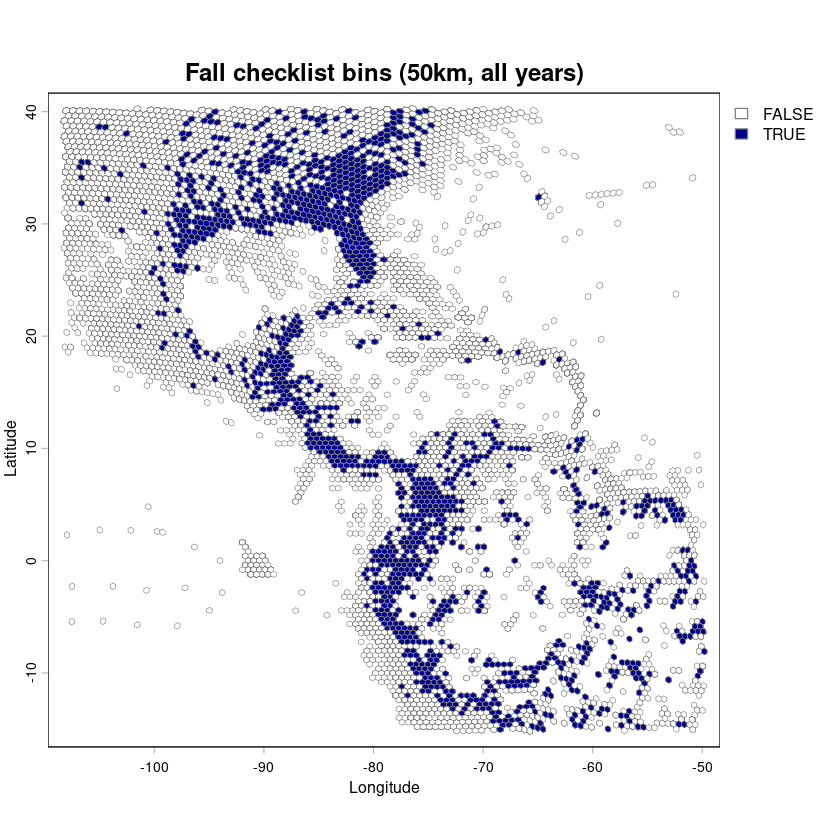

In [206]:
plot(
    hex_spatvector_colored_weekly, "cell_has_observation",
    # hex_spatvector_colored_weekly[hex_spatvector_colored_weekly$week == 44], "has_observation",
    col = c("white", "darkblue"),
    border = "gray50",
    lwd = 0.5,
    main = "Fall checklist bins (50km, all years)",
    xlab = "Longitude", ylab = "Latitude",
    )

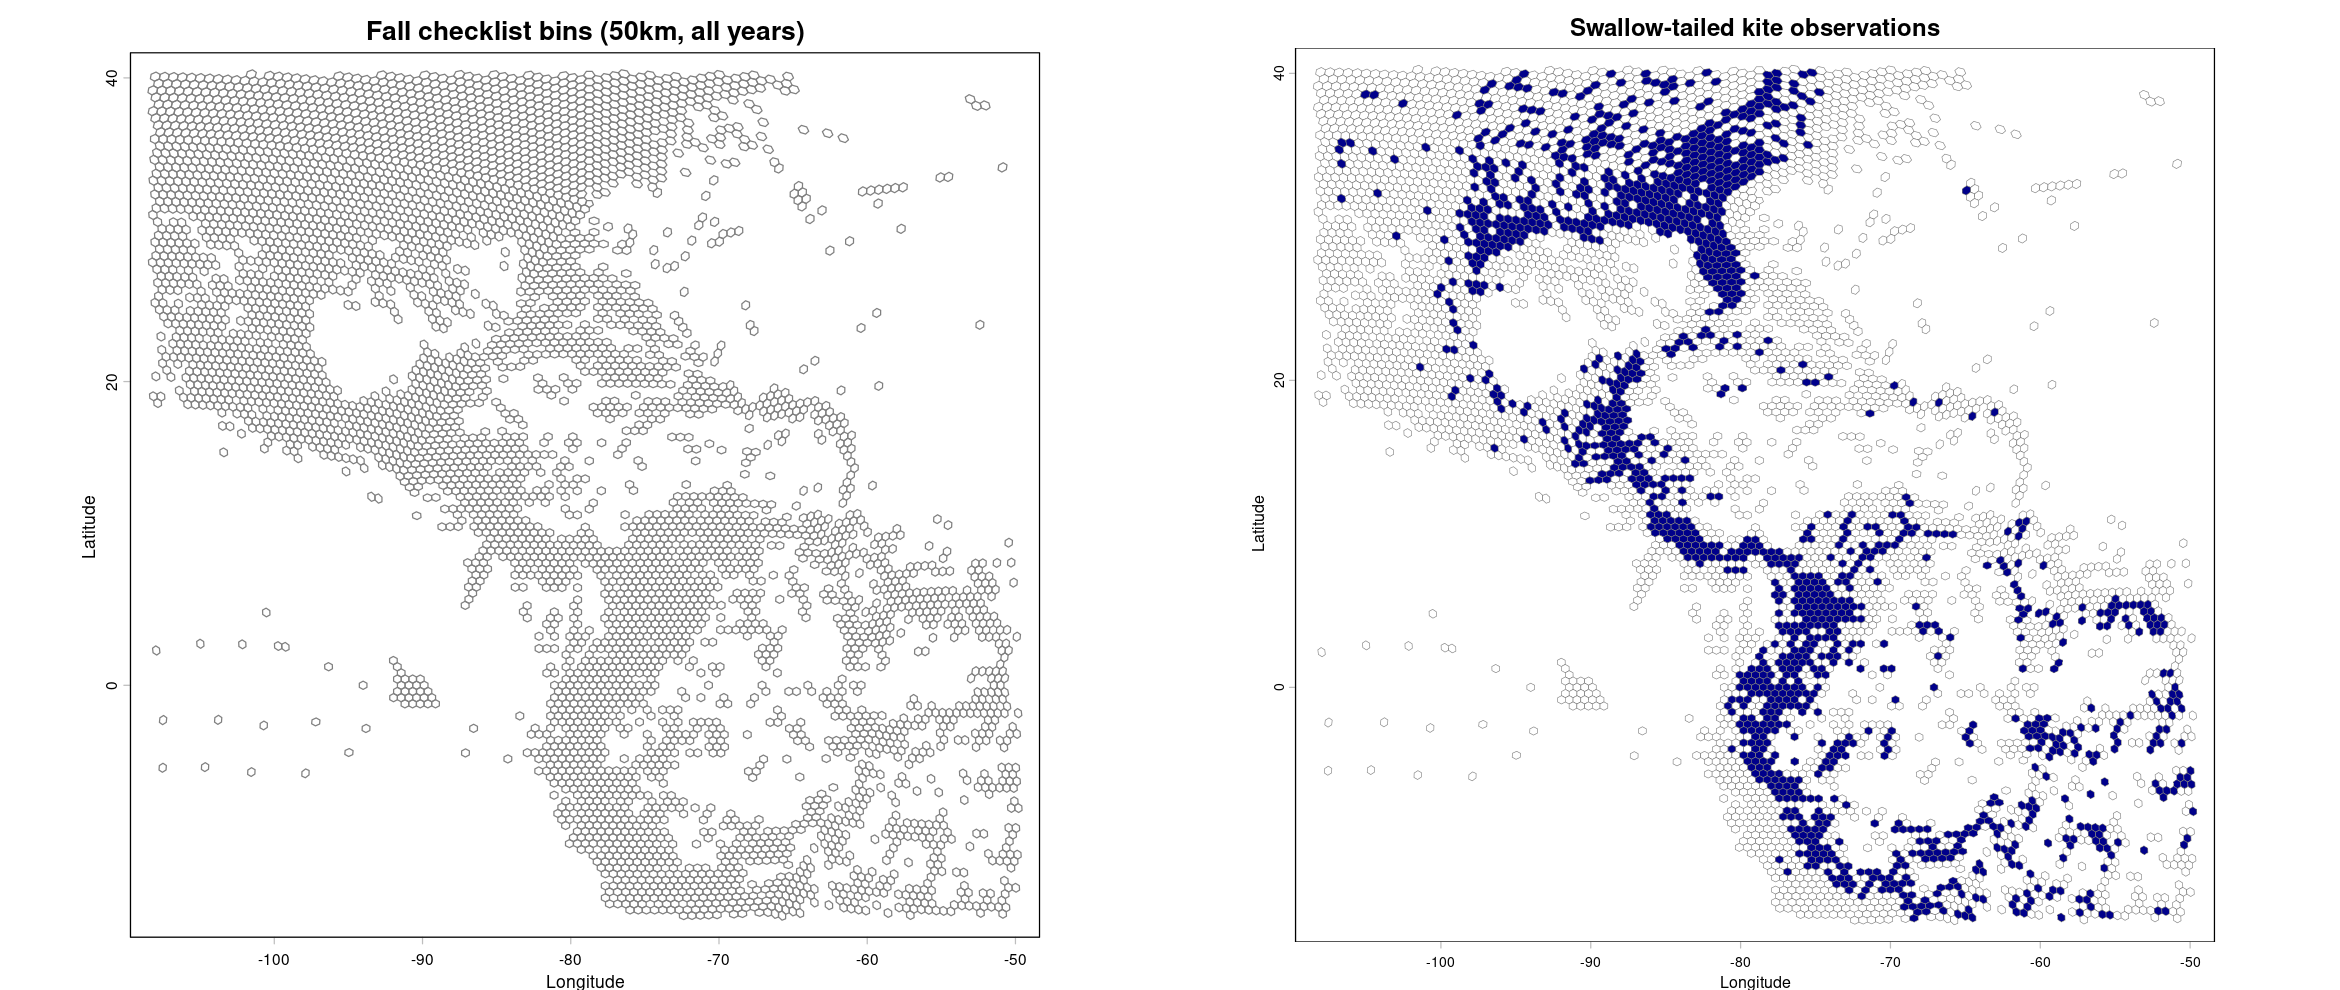

In [186]:
# Plot with custom edge color and thinner lines
# 1x2 layout; enlarge output area (~30%) for side-by-side panels in Jupyter
options(repr.plot.width = 13*1.5, repr.plot.height = 5.5*1.5)

old_par <- par(no.readonly = TRUE)
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1), cex = 1.1)

plot(
    hex_spatvector,
    border = "gray50",
    lwd = 1.0,
    main = "Fall checklist bins (50km, all years)",
    xlab = "Longitude", ylab = "Latitude"
)

par(mar = c(4, 4, 3, 4), cex = 1.0)

plot(
    hex_spatvector_colored, "has_observation",
    col = c("white", "darkblue"),
    border = "gray50",
    lwd = 0.5,
    main = "Swallow-tailed kite observations",
    xlab = "Longitude", ylab = "Latitude",
    legend = FALSE,
    yaxt = "n"
)

### <span style="color: grey">Year distribution</span>

In [ ]:
# mutate(ebd_df, 
#     obs_year = year(observation_date))
ebd_df[ebd_df["year"] == "1838",]

checklist_id,country,country_code,state,state_code,latitude,longitude,observation_date,time_observations_started,observer_id,⋯,effort_distance_km,number_observers,all_species_reported,group_identifier,scientific_name,observation_count,species_observed,hours_of_day,year,day_of_year
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<date>,<time>,<chr>,⋯,<dbl>,<dbl>,<lgl>,<chr>,<chr>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>
S32244011,United States,US,Alabama,US-AL,32.20278,-86.96184,1838-07-05,NA,obsr814273,⋯,NA,1,TRUE,NA,Ictinia mississippiensis,0,FALSE,NA,1838,186
S32258573,United States,US,Alabama,US-AL,32.20278,-86.96184,1838-09-30,NA,obsr814273,⋯,NA,1,TRUE,NA,Ictinia mississippiensis,0,FALSE,NA,1838,273
S32253298,United States,US,Alabama,US-AL,32.20278,-86.96184,1838-08-01,NA,obsr814273,⋯,NA,1,TRUE,NA,Ictinia mississippiensis,1,TRUE,NA,1838,213
S32258391,United States,US,Alabama,US-AL,32.20278,-86.96184,1838-09-17,19:30:00,obsr814273,⋯,NA,2,TRUE,NA,Ictinia mississippiensis,0,FALSE,19.5,1838,260
S32241794,United States,US,Alabama,US-AL,32.20278,-86.96184,1838-07-03,NA,obsr814273,⋯,NA,NA,TRUE,NA,Ictinia mississippiensis,0,FALSE,NA,1838,184
S32244279,United States,US,Alabama,US-AL,32.20278,-86.96184,1838-07-15,NA,obsr814273,⋯,NA,1,TRUE,NA,Ictinia mississippiensis,0,FALSE,NA,1838,196


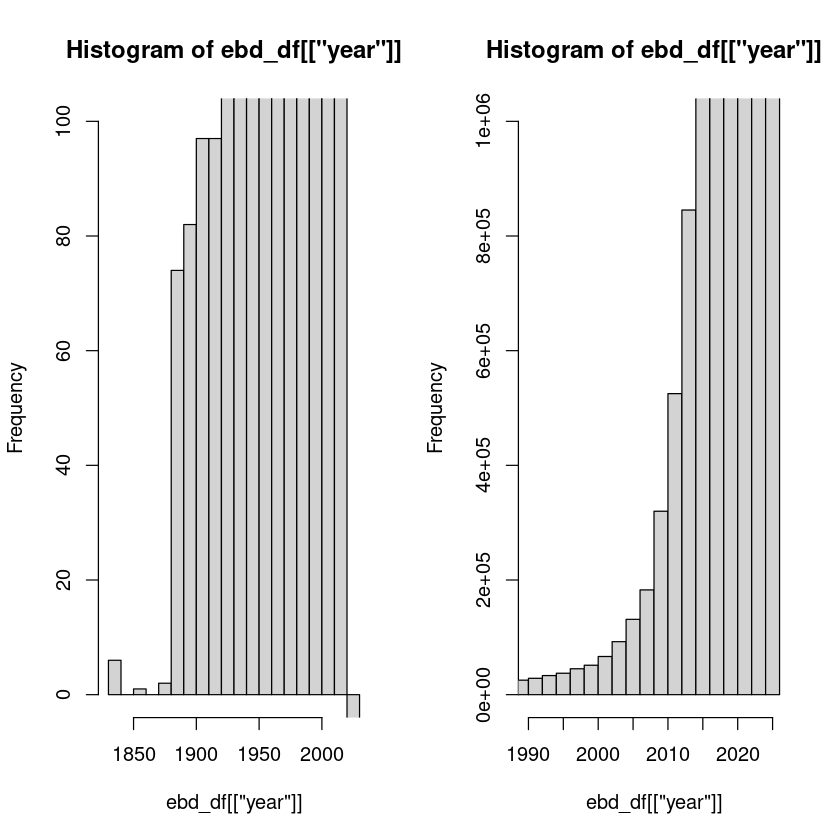

In [71]:
par(mfrow = c(1, 2))

hist(ebd_df[["year"]], ylim = c(0, 100))

hist(
    ebd_df[["year"]],
    xlim = c(1990, 2026),
    ylim = c(0, 1000000),
    breaks = 100
)